# ML_validation #

##### We will continue our training with a problem from Kaggle.com. In this chapter, we will implement all the validation schemes, some hyperparameter tuning methods, and feature selection methods described above. Measure quality metrics on training and test samples. Will detect overfitted models and regularize them. And dive deeper with native model estimation and comparison. #####


### Answer the questions from the introduction

What is leave-one-out?
leave-one-out cross validation its one module of cross validation when we have a k = n folder and we train our data for n - 1 folder and test 1 and repeat this until we train all data for each data one time for example if we have 10 folder we split it to the 10 - 1 = 9 times for training and 1 left for the test this mtehod will be iteration until all data 1 time train 


disadvantage : 
* 1 : defenitly take much time to train each data once and its not gonna be best for big amount of data time complexity - O(n) 
* 2 :  for the high variance the estimate may be overfitting or underfitting
* 3 : has the unstable estimate



### Answer the questions from the introduction

What is leave-one-out?
leave-one-out cross validation its one module of cross validation when we have a k = n folder and we train our data for n - 1 folder and test 1 and repeat this until we train all data for each data one time for example if we have 10 folder we split it to the 10 - 1 = 9 times for training and 1 left for the test this mtehod will be iteration until all data 1 time train 


disadvantage : 
* 1 : defenitly take much time to train each data once and its not gonna be best for big amount of data time complexity - O(n) 
* 2 :  for the high variance the estimate may be overfitting or underfitting
* 3 : has the unstable estimate
viusal example of   Leave_One_Out
```Python
>>> from sklearn.model_selection import LeaveOneOut

>>> X = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
>>> loo = LeaveOneOut()
>>> for train, test in loo.split(X):
...     print("%s %s" % (train, test))

[1 2 3 4 5 6 7 8 9] [0]
[0 2 3 4 5 6 7 8 9] [1]
[0 1 3 4 5 6 7 8 9] [2]
[0 1 2 4 5 6 7 8 9] [3]
[0 1 2 3 5 6 7 8 9] [4]
[0 1 2 3 4 6 7 8 9] [5]
[0 1 2 3 4 5 7 8 9] [6]
[0 1 2 3 4 5 6 8 9] [7]
[0 1 2 3 4 5 6 7 9] [8]
[0 1 2 3 4 5 6 7 8] [9] 


#  Explain classification of feature selection methods. Explain how Pearson and Chi2 work. Explain how Lasso works. Explain what permutation significance is. Become familiar with SHAP.  

## so far we have group of future selection methods 


### pearson and correlation : 
 primary work for the numerical method
it measure the linear relationship for 2 continuous variables (how constantly x and y move ) if it it will be 1 its great its 0  no relation -1 perfect opposite 
r = cov(x,y) / (σx * σy)

where:
- cov = covariance
- σ = standard deviation
- r ranges from -1 to +1


### CHI-SQUARE (χ²) TEST (For Categorical Features & Categorical Target)

it test between 2 variables and see if they have signifcant association or its just by chance they have relation toghater (observe and expect are play the main rule here) 

The Logic:
Create observed frequency table (actual counts)

Create expected frequency table (if no relationship)

Compare observed vs expected

χ² = Σ [(Observed - Expected)² / Expected]

### LASSO (Least Absolute Shrinkage and Selection Operator):

How it works:
Linear regression with L1 regularization that can shrink coefficients to exactly zero.

The Math:
text
Ordinary Regression:     Minimize MSE
Lasso Regression:        Minimize MSE + λ∑|βi|

where:
- MSE = Mean Squared Error
- λ = regularization strength (penalty)
- |βi| = absolute value of coefficients


Higher α = more regularization = more features become zero

Features with non-zero coefficients are "selected"

Perfect for high-dimensional data


### PERMUTATION SIGNIFICANCE:

What it is:
A method to test if a feature's importance is statistically significant or just by chance.

### SHAP (SHapley Additive exPlanations)

What is SHAP?
A game-theoretic approach to explain individual predictions by showing each feature's contribution.
in better way to say its add future one by one and show you how much each play the role for this prediction

# For a single prediction:
prediction = base_value + sum(feature_contributions)

# Example: House price prediction
Base price (average house):      $300,000
+ Has pool:                      +$25,000
+ 3 bedrooms:                     +$15,000
- Far from city center:           -$30,000
+ New construction:               +$40,000
= Final prediction:               $350,000 


also the game theory here means each future has the goal and based on their goal they react and some features coopration togheter  they work as group by group 


 Efficiency

All payoffs are distributed completely (sum of all Shapley values = total payoff)

2. Symmetry

If two players contribute identically to all coalitions, they get the same payoff

3. Dummy Player

If a player never contributes anything, they get nothing

4. Additivity

If you combine two games, a player's Shapley value is the sum of their values from each game



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sk
import lightgbm as lgb
import scipy as sp
import statsmodels as sm
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm import tqdm
import re

In [1]:
data = pd.read_json('../datasets/train.json')
label = LabelEncoder()
data['interest_level'] = label.fit_transform(data['interest_level'])
data.to_csv('train.csv',index=False)

NameError: name 'pd' is not defined

In [ ]:
def cleaner(data, column_name:str) -> pd.DataFrame:  # функция для очистки от аутлайеров
  q1 = data[column_name].quantile(q=0.01)
  q2 = data[column_name].quantile(q=0.99)
  cleaned_data = data[(data[column_name] > q1) & (data[column_name] < q2)].reset_index(drop=True)
  return cleaned_data

- Read all the data.
- Preprocess the "Interest Level" feature.
- Create features:  'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'.

In [ ]:
train_df = pd.read_json ("/content/drive/MyDrive/Colab Notebooks/school21/train.json")
#test_df = pd.read_json("/content/drive/MyDrive/Colab Notebooks/school21/test.json")

Чистим от выбросов:

In [ ]:
cleaned_train = cleaner(train_df, "price")

Преобразуем interest_level:

In [ ]:
interest_codes = {
    'low': 0,
    'medium': 1,
    'high': 2
}

cleaned_train['interest_level'] = cleaned_train['interest_level'].map(interest_codes)

In [ ]:
#cleaned_train.iloc[cleaned_train['interest_level'] == 'low', cleaned_train.columns == 'interest_level'] = 0
#cleaned_train.iloc[cleaned_train['interest_level'] == 'medium', cleaned_train.columns == 'interest_level'] = 1
#cleaned_train.iloc[cleaned_train['interest_level'] == 'high', cleaned_train.columns == 'interest_level'] = 2
#cleaned_train.loc[:,'interest_level'] = cleaned_train['interest_level'].astype(int)

Приводим фичи к единообразному виду:

In [ ]:
def get_info_features(data):
  def chunk_generator():
    data_chunks = [data.iloc[i:i+20] for i in range(0, len(data), 20)]
    pattern = re.compile(r'[ \]\[\'\"]+')
    #b = "[,]'\" "

    for chunk_num, chunk in enumerate(tqdm(data_chunks, desc="Обработка чанков")):
      chunk_data = []

      for index, row in chunk.iterrows():  #row - list of strings from all columns
        if not row['features']:
          chunk_data.append('')
          #print('hey')
          continue
        for string in row['features']:
          if not string.strip():
            chunk_data.append('')

          features = string.split(",")
          #print(features)
          for feature in features:
            cleaned_feature = pattern.sub('', feature, 0)
            if cleaned_feature  == '':
              chunk_data.append(cleaned_feature)
            else:
              chunk_data.append(cleaned_feature)
      yield chunk_data

  all_features = []
  for chunk_features in chunk_generator():
    all_features.extend(chunk_features)

  unique_features = set(all_features)
  row_count = len(all_features)
  unique_count = len(unique_features)

  print(f"\nВсего найдено фич: {row_count}")
  print(f"Из них уникальных фич: {unique_count}")

  return all_features, unique_features

In [ ]:
all_feat, unique_feat = get_info_features(cleaned_train)

Обработка чанков: 100%|██████████| 2418/2418 [00:02<00:00, 819.90it/s]



Всего найдено фич: 265483
Из них уникальных фич: 1530


In [ ]:
feature_list = ['Elevator', 'HardwoodFloors', 'CatsAllowed',
                'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee',
                'LaundryinBuilding', 'FitnessCenter', 'Pre-War',
                'LaundryinUnit', 'RoofDeck', 'OutdoorSpace',
                'DiningRoom', 'HighSpeedInternet', 'Balcony',
                'SwimmingPool', 'LaundryInBuilding',
                'NewConstruction', 'Terrace']

In [ ]:
def features_encoder(df, feature_list):
    pd.options.mode.copy_on_write = True
    pattern = re.compile(r'[\]\[\'\" ]+')

    for index, row in df.iterrows():
        features = []
        if not row['features']:
            features.append('')
        else:
            for string in row['features']:
                if not string.strip():
                    features.append('')
                    continue

                feature_string = pattern.sub('', string, 0)
                feature_string = feature_string.split(",")

                for feat in feature_string:
                    if not feat.strip():
                        features.append('')
                    else:
                        features.append(feat)

        for new_feat in feature_list:
          if new_feat in features:
              df.loc[index, new_feat] = 1
          else:
              df.loc[index, new_feat] = 0

    return df

In [ ]:
train_df = features_encoder(cleaned_train, feature_list)

In [ ]:
col_to_del = ['building_id', 'description', 'display_address',
              'features', 'listing_id', 'manager_id', 'photos',
              'street_address', 'latitude', 'longitude']
for col in col_to_del:
  if col in train_df.columns:
      train_df.drop(col, axis=1, inplace=True)
train_df.sample(5)

,bathrooms,bedrooms,created,price,interest_level,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
20142,1.0,2,2016-05-03 05:53:27,2625,1,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
45734,1.0,0,2016-04-21 05:05:45,2800,0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
29751,2.0,3,2016-05-12 06:20:04,4900,0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13812,1.0,0,2016-06-11 02:35:30,1650,2,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
43670,1.0,0,2016-04-10 05:13:31,1500,0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train_df.to_csv('train.csv', index=False)

In [ ]:
Y_train = train_df['price']
X_train = train_df.drop('price', axis=1)

In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48343 entries, 0 to 48342
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bathrooms          48343 non-null  float64
 1   bedrooms           48343 non-null  int64  
 2   created            48343 non-null  object 
 3   interest_level     48343 non-null  int64  
 4   Elevator           48343 non-null  float64
 5   HardwoodFloors     48343 non-null  float64
 6   CatsAllowed        48343 non-null  float64
 7   DogsAllowed        48343 non-null  float64
 8   Doorman            48343 non-null  float64
 9   Dishwasher         48343 non-null  float64
 10  NoFee              48343 non-null  float64
 11  LaundryinBuilding  48343 non-null  float64
 12  FitnessCenter      48343 non-null  float64
 13  Pre-War            48343 non-null  float64
 14  LaundryinUnit      48343 non-null  float64
 15  RoofDeck           48343 non-null  float64
 16  OutdoorSpace       483

# 3. Implement the next methods:

- Split data into 2 parts randomly with parameter test_size (ratio from 0 to 1), return training and test samples.

In [ ]:
def train_test_split21(
        X: pd.DataFrame,
        y: pd.Series,
        test_size: float = 0.2,
        random_state: int = 21,
        shuffle: bool = True
    ):

    n = len(X)

    if n < 2:
        raise ValueError('Need at least 2 samples to split')
    if len(y) != n:
        raise ValueError(f"X and y have different lengths: {n} vs {len(y)}")
    if not (0.0 < float(test_size) < 1.0):
        raise ValueError(f"test_size must be in (0,1), got {test_size}")

    #rng = np.random.default_rng(seed=random_state)
    #rng = np.random.seed(random_state)
    # можно использовать другие функции для генерации рандома,
    # но в реализации sklearn видимо эта:
    rng = np.random.RandomState(random_state)
    idx = np.arange(n)
    perm = rng.permutation(idx) if shuffle else idx

    n_test = int(np.ceil(n * float(test_size)))
    n_test = min(n-1,n_test)

    test_idx = perm[:n_test]
    train_idx = perm[n_test:]


    if isinstance(X, pd.DataFrame):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    else:
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

    return X_train, X_test, y_train, y_test


In [ ]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_Y, test_Y = train_test_split(X_train, Y_train, test_size=0.3, random_state=21)

In [ ]:
X_train_check, X_test_check, Y_train_check, Y_test_check = train_test_split21(X_train, Y_train, test_size=0.3)

In [ ]:
print(train_X.equals(X_train_check))
print(test_X.equals(X_test_check))
print(train_Y.equals(Y_train_check))
print(test_Y.equals(Y_test_check ))

True
True
True
True


- Randomly split data into 3 parts with parameters validation_size and test_size, return train, validation and test samples.

In [ ]:
def train_val_test_split21(
    X:pd.DataFrame,
    y:pd.Series,
    random_state: int = 21,
    validation_size:float=0.2,
    test_size:float=0.2,
    shuffle: bool=True
    ):

    n = len(X)

    if n < 2:
        raise ValueError('Need at least 2 samples to split')
    if len(y) != n:
        raise ValueError(f"X and y have different lengths: {n} vs {len(y)}")
    if not (0.0 < float(test_size) < 1.0):
        raise ValueError(f"test_size must be in (0,1), got {test_size}")

    rng = np.random.RandomState(random_state)
    idx = np.arange(n)
    perm = rng.permutation(idx) if shuffle else idx

    n_train = int(np.ceil(n * (1 - (float(test_size) + float(validation_size)))))
    n_valid = n - int(np.ceil(n * float(test_size)))

    train_idx = perm[:n_train]
    test_idx = perm[n_train: n_valid]
    valid_idx = perm[n_valid:]


    if isinstance(X, pd.DataFrame):
        X_train, X_valid, X_test = X.iloc[train_idx],X.iloc[valid_idx], X.iloc[test_idx]
        y_train, y_valid, y_test = y.iloc[train_idx],y.iloc[valid_idx], y.iloc[test_idx]
    else:
        X_train, X_valid, X_test = X[train_idx], X[valid_idx], X[test_idx]
        y_train, y_valid, y_test = y[train_idx], y[valid_idx], y[test_idx]

    return X_train, X_valid, X_test, y_train, y_valid, y_test


In [ ]:
X_train_check, X_valid_check, X_test_check, Y_train_check, Y_valid_check, Y_test_check = train_val_test_split21(X_train, Y_train, test_size=0.3, validation_size=0.3)

In [ ]:
print(len(X_train_check), len(X_valid_check), len(X_test_check))

19338 14503 14502


- Split data into 2 parts with parameter date_split, return train and test samples split by date_split param.

In [ ]:
def train_test_split_by_date(
        X: pd.DataFrame,
        y: pd.Series,
        date_col: str,
        date_split: str,
        drop_na_dates: bool = True,
        sort_by_time: bool = True
    ):

    if not X.index.equals(y.index):
        raise ValueError("X and y indices do not match")
    if date_col not in X.columns:
        raise ValueError(f"Column '{date_col}' not found in X")
    dates = pd.to_datetime(X[date_col], errors="coerce",utc=True)
    cut = pd.to_datetime(date_split,utc=True)

    if drop_na_dates:
        keep = dates.notna()
        X, y, dates = X.loc[keep], y.loc[keep], dates.loc[keep]

    if sort_by_time:
        order = dates.sort_values().index
        X, y, dates = X.loc[order], y.loc[order], dates.loc[order]
    mask = (dates <= cut)
    X_train, y_train = X.loc[mask], y.loc[mask]
    X_test,  y_test  = X.loc[~mask], y.loc[~mask]
    return X_train, X_test, y_train, y_test

In [ ]:
train_df_date = pd.read_csv("train.csv")
Y_train_date = train_df_date['price']
X_train_date = train_df_date.drop('price', axis=1)

In [ ]:
#X_train_date.sample(5)

In [ ]:
X_train_time, X_test_time, Y_train_time, Y_test_time = train_test_split_by_date(X_train_date, Y_train_date, date_col='created', date_split='2016-04-24 15:03:53')

In [ ]:
print(len(X_train_time), len(X_test_time), len(Y_train_time), len(Y_test_time))

12761 35582 12761 35582


- Split data into 3 parts with parameters validation_date and test_date, return train, validation and test samples split by input params.
Make split procedure determenistic. What does it mean?
- зафиксировать либо даты для валидационного и тестового, либо рандом сид при разбиении

In [ ]:
def train_val_test_split_by_date(
        X: pd.DataFrame,
        y: pd.Series,
        date_col: str,
        validation_date:str,
        test_date:str,
        drop_na_dates: bool = True,
        sort_by_time: bool = True
    ):

    if not X.index.equals(y.index):
        raise ValueError("X and y indices do not match")
    if date_col not in X.columns:
        raise ValueError(f"Column '{date_col}' not found in X")

    dates = pd.to_datetime(X[date_col], errors="coerce",utc=True)
    val_cut = pd.to_datetime(validation_date,utc=True)
    test_cut = pd.to_datetime(test_date,utc=True)
    if val_cut > test_cut:
        raise ValueError(f"Validation date {validation_date} should be less than test date {test_date}")

    if drop_na_dates:
        keep = dates.notna()
        X, y, dates = X.loc[keep], y.loc[keep], dates.loc[keep]

    if sort_by_time:
        order = dates.sort_values().index
        X, y, dates = X.loc[order], y.loc[order], dates.loc[order]
    train_mask = (dates <= val_cut)
    valid_mask = ((dates <= test_cut) & (dates > val_cut))
    test_mask = (dates > test_cut)

    X_train, y_train = X.loc[train_mask], y.loc[train_mask]
    X_valid, y_valid = X.loc[valid_mask], y.loc[valid_mask]
    X_test,  y_test  = X.loc[test_mask], y.loc[test_mask]
    return X_train, X_valid, X_test, y_train, y_valid, y_test

In [ ]:
X_train_time, X_valid_time, X_test_time, Y_train_time,Y_valid_time, Y_test_time = train_val_test_split_by_date(X_train_date, Y_train_date, date_col='created', validation_date='2016-04-24 15:03:53', test_date='2016-06-16 03:11:58')

In [ ]:
print(len(X_train_time), len(X_valid_time), len(X_test_time), len(Y_train_time), len(Y_valid_time),len(Y_test_time))

12761 28184 7398 12761 28184 7398


In [ ]:
print(max(X_train_time["created"]))
print(max(X_valid_time["created"]))
print(max(X_test_time["created"]))

2016-04-24 15:03:53
2016-06-16 03:11:58
2016-06-29 21:41:47


In [ ]:
def train_val_test_split_by_date(
        X: pd.DataFrame,
        y: pd.Series,
        date_col: str,
        train_ratio: float = 0.6,
        val_ratio: float = 0.2,
        random_state: int = 21,
        drop_na_dates: bool = True
    ):

    if not X.index.equals(y.index):
        raise ValueError("X and y indices do not match")
    if date_col not in X.columns:
        raise ValueError(f"Column '{date_col}' not found in X")

    X_copy = X.copy()
    y_copy = y.copy()

    dates = pd.to_datetime(X_copy[date_col], errors="coerce", utc=True)

    if drop_na_dates:
        keep = dates.notna()
        X_copy, y_copy, dates = X_copy.loc[keep], y_copy.loc[keep], dates.loc[keep]

    sorted_indices = dates.sort_values().index
    X_sorted = X_copy.loc[sorted_indices]
    y_sorted = y_copy.loc[sorted_indices]
    dates_sorted = dates.loc[sorted_indices]

    total_size = len(X_sorted)
    train_size = int(train_ratio * total_size)
    val_size = int(val_ratio * total_size)


    train_indices = range(0, train_size)
    val_indices = range(train_size, train_size + val_size)
    test_indices = range(train_size + val_size, total_size)


    X_train, y_train = X_sorted.iloc[train_indices], y_sorted.iloc[train_indices]
    X_val, y_val = X_sorted.iloc[val_indices], y_sorted.iloc[val_indices]
    X_test, y_test = X_sorted.iloc[test_indices], y_sorted.iloc[test_indices]
    return X_train, X_val, X_test, y_train, y_val, y_test

In [ ]:
X_train_time, X_valid_time, X_test_time, Y_train_time,Y_valid_time, Y_test_time = train_val_test_split_by_date(X_train_date, Y_train_date, date_col='created')

In [ ]:
print(len(X_train_time), len(X_valid_time), len(X_test_time), len(Y_train_time), len(Y_valid_time),len(Y_test_time))

29005 9668 9670 29005 9668 9670


In [ ]:
print(max(X_train_time["created"]))
print(max(X_valid_time["created"]))
print(max(X_test_time["created"]))

2016-05-24 16:34:40
2016-06-12 08:07:17
2016-06-29 21:41:47


# 4. Implement the next cross-validation methods:

- K-Fold, where k is the input parameter, returns a list of train and test indices.
- Grouped K-Fold, where k and group_field are input parameters, returns list of train and test indices.
- Stratified K-fold, where k and stratify_field are input parameters, returns list of train and test indices.
- Time series split, where k and date_field are input parameters, returns list of train and test indices.

In [ ]:
class KFold_21():
  def __init__(self, k, shuffle=True, random_state=21):
    if k < 2:
      raise ValueError("k as a number of splits should be greater than 1!")
    self.k = k
    self.shuffle = shuffle
    self.random_state = random_state

  def split(self, X):
    n = len(X)

    if n < self.k:
      raise ValueError("Number of samples should be greater than number of splits!")

    if self.shuffle: #перемешиваем
      rng = np.random.RandomState(self.random_state)
      idx = rng.permutation(np.arange(n))
    else: idx = np.arange(n)

    fold_sizes = np.full(self.k, n//self.k, dtype=int)
    #распределяем остатки с первых фолдов
    fold_sizes[:(n % self.k)] +=1

    now = 0
    for i in range(self.k):
      start, stop = now, now+fold_sizes[i]
      test_idx = idx[start:stop]
      train_idx = np.concatenate([idx[:start], idx[stop:]])
      now = stop
      yield np.sort(train_idx), np.sort(test_idx)

In [ ]:
class Group_KFold_21():
  def __init__(self, k, shuffle=True, random_state=21):
    if k < 2:
      raise ValueError("k as a number of splits should be greater than 1!")
    self.k = k
    self.shuffle = shuffle
    self.random_state = random_state

  def split(self, X, groups):
    n = len(X)
    groups = np.asarray(groups)
    g_unique, g_codes = np.unique(groups, return_inverse=True)
    groups_number = len(g_unique)

    if (groups_number > self.k):
      raise ValueError(f"Number of groups {groups_number} should be less or at least equal to the number of folds {self.k}!")
    if (groups_number > n):
      raise ValueError(f"Number of groups {groups_number} should be less or at least equal to the number of samples {n}!")

    group_idx = np.arange(groups_number)
    if self.shuffle:
      rng = np.random.RandomState(self.random_state)
      group_idx = rng.permutation(group_idx)

    #вместо сэмплов распределяем группы
    fold_sizes = np.full(self.k, groups_number//self.k, dtype=int)
    fold_sizes[:(groups_number % self.k)] += 1

    rows_by_group = []
    for gi in range(groups_number):
      mask = g_codes == gi
      indices = np.flatnonzero(mask)
      rows_by_group.append(indices)

    now = 0
    for i in range(self.k):
      start, stop = now, now+fold_sizes[i]
      test_group = group_idx[start:stop]
      now = stop

      if test_group.size == 0:
        test_idx = np.array([], dtype=int)
      else:
        test_idx = np.concatenate([rows_by_group[gi] for gi in test_group]).astype(int, copy=False)

      mask = np.ones(n, dtype=bool)
      mask[test_idx] = False
      train_idx = np.flatnonzero(mask)

      yield np.sort(train_idx), np.sort(test_idx)


In [ ]:
class Stratified_KFold_21():
  def __init__(self, k, shuffle=True, random_state=21):
    if k < 2:
      raise ValueError("k as a number of splits should be greater than 1!")
    self.k = k
    self.shuffle = shuffle
    self.random_state = random_state

  def split(self, X, groups):
    n = len(X)
    groups = np.asarray(groups)
    if (len(groups) < self.k):
      raise ValueError(f"Number of groups {len(groups)} should be less or at least equal to the number of folds {self.k}!")

    y_unique, y_codes, y_counts = np.unique(groups, return_inverse=True, return_counts=True)

    if len(y_unique) < 2:
      raise ValueError("Need at least 2 classes for stratification")
    if np.any(y_counts < self.k):
      raise ValueError("Each class must have at least k samples for stratified k-fold")

    idx_by_class = [np.flatnonzero(y_codes == ci) for ci in range(len(y_unique))]
    rng = np.random.RandomState(self.random_state)
    if self.shuffle:
      for arr in idx_by_class:
          rng.shuffle(arr)

    #расчет размера фолдов
    fold_sizes_per_class = [np.full(self.k, c // self.k, int) for c in y_counts]
    for fs, c in zip(fold_sizes_per_class, y_counts):
      fs[: (c % self.k)] += 1

    #распределение сэмплов по фолдам
    folds = [[] for _ in range(self.k)]
    for cls_idx, arr in enumerate(idx_by_class):
      now = 0
      for i in range(self.k):
        size = fold_sizes_per_class[cls_idx][i]
        folds[i].extend(arr[now:now + size])
        now += size

    #генерация сплитов
    for i in range(self.k):
      test_idx = np.array(folds[i])
      mask = np.ones(n, dtype=bool)
      mask[test_idx] = False
      train_idx = np.flatnonzero(mask)
      yield np.sort(train_idx), np.sort(test_idx)

In [ ]:
class Time_Series_Split21():
    def __init__(self, n_splits):
        self.n_splits = n_splits

    def split(self, X, date_field):
        n = len(X[date_field])
        if n != X.shape[0]:
            raise ValueError(f'Numbers of rows in X({X.shape[0]}) is not equal to the numbers of rows in date_field ({n})')

        X[date_field] = pd.to_datetime(X[date_field])
        X = X.sort_values(by=date_field)

        fold_sizes = np.full(self.n_splits + 1, X.shape[0] // (self.n_splits + 1), dtype=int)
        fold_sizes[: (X.shape[0] % self.n_splits)] += 1

        idx = np.arange(n)

        now = 0
        for i in range(0, self.n_splits):
            start, stop = 0, now + fold_sizes[i]
            train_idx = idx[start:stop]
            test_idx = idx[stop:stop + fold_sizes[i + 1]]
            now = stop
            yield train_idx, test_idx


# 5. Cross-validation comparison

- Apply all the validation methods implemented above to our dataset. To apply Stratified algorithm you should preprocess target.
- Apply the appropriate methods from sklearn.
- Compare the resulting feature distributions for the training part of the dataset between sklearn and your implementation.
- Compare all validation schemes. Choose the best one. Explain your choice.

In [ ]:
from sklearn.model_selection import KFold, GroupKFold, StratifiedKFold, TimeSeriesSplit

In [ ]:
train_df = pd.read_csv("train.csv")
train_df.sample(5)

,bathrooms,bedrooms,created,price,interest_level,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
8434,1.0,0,2016-06-29 04:32:36,2300,0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10557,2.0,2,2016-06-16 02:22:58,6998,0,1.0,0.0,1.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
34401,1.0,1,2016-04-24 01:18:53,3250,0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13782,1.0,1,2016-06-22 04:33:01,3600,0,1.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
26582,1.0,2,2016-05-12 05:01:28,4995,0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# функция для сравнения
def compare_train_distributions(X_train_own, X_train_skl):
    stats = pd.DataFrame({
        'mean_own': X_train_own.mean(numeric_only=True),
        'mean_skl': X_train_skl.mean(numeric_only=True),
        'std_own':  X_train_own.std(numeric_only=True, ddof=0),
        'std_skl':  X_train_skl.std(numeric_only=True, ddof=0),
    })
    stats['Δmean'] = (stats['mean_own'] - stats['mean_skl']).abs()
    stats['Δstd']  = (stats['std_own']  - stats['std_skl']).abs()
    return stats.sort_values('Δmean', ascending=False)

## Обычный KFold

In [ ]:
kf21 = KFold_21(5, shuffle=True)
for train_idx, test_idx in kf21.split(X_train.iloc[:30]):
    print(train_idx, test_idx)

[ 0  2  3  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 24 25 26 27 29] [ 1  5 21 22 23 28]
[ 0  1  2  3  4  5  6  8  9 10 12 13 14 15 16 17 20 21 22 23 24 25 28 29] [ 7 11 18 19 26 27]
[ 1  2  3  4  5  7  8  9 10 11 14 15 16 17 18 19 21 22 23 24 25 26 27 28] [ 0  6 12 13 20 29]
[ 0  1  4  5  6  7  9 11 12 13 15 16 18 19 20 21 22 23 24 25 26 27 28 29] [ 2  3  8 10 14 17]
[ 0  1  2  3  5  6  7  8 10 11 12 13 14 17 18 19 20 21 22 23 26 27 28 29] [ 4  9 15 16 24 25]


In [ ]:
kf = KFold(5, random_state=21, shuffle=True)
for train_idx, test_idx in kf.split(X_train.iloc[:30]):
    print(train_idx, test_idx)

[ 0  2  3  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 24 25 26 27 29] [ 1  5 21 22 23 28]
[ 0  1  2  3  4  5  6  8  9 10 12 13 14 15 16 17 20 21 22 23 24 25 28 29] [ 7 11 18 19 26 27]
[ 1  2  3  4  5  7  8  9 10 11 14 15 16 17 18 19 21 22 23 24 25 26 27 28] [ 0  6 12 13 20 29]
[ 0  1  4  5  6  7  9 11 12 13 15 16 18 19 20 21 22 23 24 25 26 27 28 29] [ 2  3  8 10 14 17]
[ 0  1  2  3  5  6  7  8 10 11 12 13 14 17 18 19 20 21 22 23 26 27 28 29] [ 4  9 15 16 24 25]


In [ ]:
for fold, ((tr_own, _), (tr_skl, _)) in enumerate(zip(kf21.split(train_df), kf.split(train_df))):
    X_train_own = train_df.iloc[tr_own]
    X_train_skl = train_df.iloc[tr_skl]
    stats = compare_train_distributions(X_train_own, X_train_skl)
    print(f'KFold fold={fold}: max Δmean={stats["Δmean"].max():.6f}, max Δstd={stats["Δstd"].max():.6f}')
    display(stats.head(5))

KFold fold=0: max Δmean=0.000000, max Δstd=0.000000


,mean_own,mean_skl,std_own,std_skl,Δmean,Δstd
bathrooms,1.193980,1.193980,0.454183,0.454183,0.0,0.0
bedrooms,1.534183,1.534183,1.097691,1.097691,0.0,0.0
price,3535.823783,3535.823783,1580.460676,1580.460676,0.0,0.0
interest_level,0.376946,0.376946,0.617715,0.617715,0.0,0.0
Elevator,0.525133,0.525133,0.499368,0.499368,0.0,0.0


KFold fold=1: max Δmean=0.000000, max Δstd=0.000000


,mean_own,mean_skl,std_own,std_skl,Δmean,Δstd
bathrooms,1.196566,1.196566,0.458036,0.458036,0.0,0.0
bedrooms,1.535657,1.535657,1.102158,1.102158,0.0,0.0
price,3542.240446,3542.240446,1595.765007,1595.765007,0.0,0.0
interest_level,0.377773,0.377773,0.619091,0.619091,0.0,0.0
Elevator,0.525288,0.525288,0.499360,0.499360,0.0,0.0


KFold fold=2: max Δmean=0.000000, max Δstd=0.000000


,mean_own,mean_skl,std_own,std_skl,Δmean,Δstd
bathrooms,1.194330,1.194330,0.456016,0.456016,0.0,0.0
bedrooms,1.533382,1.533382,1.103402,1.103402,0.0,0.0
price,3532.140172,3532.140172,1586.617839,1586.617839,0.0,0.0
interest_level,0.377437,0.377437,0.619025,0.619025,0.0,0.0
Elevator,0.522754,0.522754,0.499482,0.499482,0.0,0.0


KFold fold=3: max Δmean=0.000000, max Δstd=0.000000


,mean_own,mean_skl,std_own,std_skl,Δmean,Δstd
bathrooms,1.194505,1.194505,0.455096,0.455096,0.0,0.0
bedrooms,1.533575,1.533575,1.102517,1.102517,0.0,0.0
price,3533.399741,3533.399741,1589.943320,1589.943320,0.0,0.0
interest_level,0.378513,0.378513,0.618649,0.618649,0.0,0.0
Elevator,0.526180,0.526180,0.499314,0.499314,0.0,0.0


KFold fold=4: max Δmean=0.000000, max Δstd=0.000000


,mean_own,mean_skl,std_own,std_skl,Δmean,Δstd
bathrooms,1.193872,1.193872,0.454393,0.454393,0.0,0.0
bedrooms,1.534221,1.534221,1.100619,1.100619,0.0,0.0
price,3532.232088,3532.232088,1575.154714,1575.154714,0.0,0.0
interest_level,0.374609,0.374609,0.615983,0.615983,0.0,0.0
Elevator,0.525120,0.525120,0.499369,0.499369,0.0,0.0


## Grouped KFold

In [ ]:
gkf21 = Group_KFold_21(4, shuffle=True)
for train_idx, test_idx in gkf21.split(train_df.iloc[110:130], train_df['bedrooms'].iloc[110:130]):
    print(train_idx, test_idx, list(train_df['bedrooms'].iloc[110:130]))

[ 0  1  3  5  6  7  8 10 11 12 13 14 15 16] [ 2  4  9 17 18 19] [1, 1, 3, 1, 3, 1, 1, 2, 2, 3, 2, 1, 1, 1, 0, 2, 2, 3, 3, 3]
[ 0  1  2  3  4  5  6  9 11 12 13 14 17 18 19] [ 7  8 10 15 16] [1, 1, 3, 1, 3, 1, 1, 2, 2, 3, 2, 1, 1, 1, 0, 2, 2, 3, 3, 3]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 15 16 17 18 19] [14] [1, 1, 3, 1, 3, 1, 1, 2, 2, 3, 2, 1, 1, 1, 0, 2, 2, 3, 3, 3]
[ 2  4  7  8  9 10 14 15 16 17 18 19] [ 0  1  3  5  6 11 12 13] [1, 1, 3, 1, 3, 1, 1, 2, 2, 3, 2, 1, 1, 1, 0, 2, 2, 3, 3, 3]


In [ ]:
gkf = GroupKFold(4, random_state=21, shuffle=True)
for train_idx, test_idx in gkf.split(train_df.iloc[110:130], groups = train_df['bedrooms'].iloc[110:130]):
    print(train_idx, test_idx, list(train_df['bedrooms'].iloc[110:130]))

[ 0  1  3  5  6  7  8 10 11 12 13 14 15 16] [ 2  4  9 17 18 19] [1, 1, 3, 1, 3, 1, 1, 2, 2, 3, 2, 1, 1, 1, 0, 2, 2, 3, 3, 3]
[ 0  1  2  3  4  5  6  9 11 12 13 14 17 18 19] [ 7  8 10 15 16] [1, 1, 3, 1, 3, 1, 1, 2, 2, 3, 2, 1, 1, 1, 0, 2, 2, 3, 3, 3]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 15 16 17 18 19] [14] [1, 1, 3, 1, 3, 1, 1, 2, 2, 3, 2, 1, 1, 1, 0, 2, 2, 3, 3, 3]
[ 2  4  7  8  9 10 14 15 16 17 18 19] [ 0  1  3  5  6 11 12 13] [1, 1, 3, 1, 3, 1, 1, 2, 2, 3, 2, 1, 1, 1, 0, 2, 2, 3, 3, 3]


## Stratified KFold

In [ ]:
bins = [0, 2000, 2500, 4100, 5800, float("inf")]
labels = ["very_low", "low", "mid", "high", "luxury"]
y_train_labeled = pd.cut(Y_train, bins=bins, labels=labels, right=False)
y_train_labeled.value_counts()

,count
price,
mid,24613
high,7791
low,7528
very_low,4294
luxury,4117


In [ ]:
y_small = y_train_labeled[:50]
skf21 = Stratified_KFold_21(4, shuffle=False)
for train_idx, test_idx in skf21.split(train_df.iloc[:50], y_small):
    print(f'Indices:')
    print(f'Train: {train_idx}')
    print(f'Test: {test_idx}')
    print(f"""Count of classes:
          {list(y_small.iloc[train_idx].value_counts())},
          {list(y_small.iloc[test_idx].value_counts())},
          {list(y_small.value_counts())}\n""")

Indices:
Train: [ 6  9 13 15 16 18 19 20 21 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37
 38 39 40 41 42 43 44 45 46 47 48 49]
Test: [ 0  1  2  3  4  5  7  8 10 11 12 14 17 22]
Count of classes:
          [18, 6, 6, 3, 3],
          [6, 3, 3, 1, 1],
          [24, 9, 9, 4, 4]

Indices:
Train: [ 0  1  2  3  4  5  7  8  9 10 11 12 14 17 21 22 27 28 29 30 32 33 34 35
 36 37 38 39 40 41 42 43 44 45 46 47 48 49]
Test: [ 6 13 15 16 18 19 20 23 24 25 26 31]
Count of classes:
          [18, 7, 7, 3, 3],
          [6, 2, 2, 1, 1],
          [24, 9, 9, 4, 4]

Indices:
Train: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 31 35 39 40 41 42 43 44 46 47 48 49]
Test: [ 9 27 28 29 30 32 33 34 36 37 38 45]
Count of classes:
          [18, 7, 7, 3, 3],
          [6, 2, 2, 1, 1],
          [24, 9, 9, 4, 4]

Indices:
Train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 22 23 24
 25 26 27 28 29 30 31 32 33 34 36 37 38 45]
Test: [21 35 39 40 41 42 43 44 46

In [ ]:
y_small = y_train_labeled[:50]
skf = StratifiedKFold(4)
for train_idx, test_idx in skf.split(train_df.iloc[:50], y_small):
    print(f'Indices:')
    print(f'Train: {train_idx}')
    print(f'Test: {test_idx}')
    print(f"""Count of classes:
          {list(y_small.iloc[train_idx].value_counts())},
          {list(y_small.iloc[test_idx].value_counts())},
          {list(y_small.value_counts())}\n""")

Indices:
Train: [ 6  9 13 15 16 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36
 37 38 39 40 41 42 43 44 45 46 47 48 49]
Test: [ 0  1  2  3  4  5  7  8 10 11 12 14 17]
Count of classes:
          [18, 7, 6, 3, 3],
          [6, 3, 2, 1, 1],
          [24, 9, 9, 4, 4]

Indices:
Train: [ 0  1  2  3  4  5  7  8  9 10 11 12 14 17 21 27 28 29 30 32 33 34 35 36
 37 38 39 40 41 42 43 44 45 46 47 48 49]
Test: [ 6 13 15 16 18 19 20 22 23 24 25 26 31]
Count of classes:
          [18, 7, 6, 3, 3],
          [6, 3, 2, 1, 1],
          [24, 9, 9, 4, 4]

Indices:
Train: [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 31 35 39 40 41 42 43 44 46 47 48 49]
Test: [ 9 27 28 29 30 32 33 34 36 37 38 45]
Count of classes:
          [18, 7, 7, 3, 3],
          [6, 2, 2, 1, 1],
          [24, 9, 9, 4, 4]

Indices:
Train: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 22 23 24
 25 26 27 28 29 30 31 32 33 34 36 37 38 45]
Test: [21 35 39 40 41 42 43 44 46

## TimeSeries

In [ ]:
tss21 = Time_Series_Split21(3)
tss = TimeSeriesSplit(3)
X_sorted = train_df.copy().sort_values('created')

In [ ]:
for fold, ((tr_own, _), (tr_skl, _)) in enumerate(zip(tss21.split(train_df, 'created'), tss.split(X_sorted))):
    X_train_own = train_df.iloc[tr_own]
    X_train_skl = train_df.iloc[tr_skl]
    stats = compare_train_distributions(X_train_own, X_train_skl)
    print(f'TSS fold={fold}: max Δmean={stats["Δmean"].max():.6f}, max Δstd={stats["Δstd"].max():.6f}')
    display(stats.head(5))

TSS fold=0: max Δmean=0.121344, max Δstd=0.096758


,mean_own,mean_skl,std_own,std_skl,Δmean,Δstd
price,3541.597882,3541.719226,1577.460018,1577.363260,0.121344,0.096758
Terrace,0.044018,0.044176,0.205135,0.205486,0.000158,0.000351
OutdoorSpace,0.102267,0.102416,0.302999,0.303194,0.000149,0.000195
Dishwasher,0.409978,0.410076,0.491829,0.491847,0.000098,0.000018
HardwoodFloors,0.473771,0.473858,0.499312,0.499316,0.000087,0.000005


TSS fold=1: max Δmean=0.033013, max Δstd=0.035957


,mean_own,mean_skl,std_own,std_skl,Δmean,Δstd
price,3551.987257,3552.020271,1596.513548,1596.477591,0.033013,0.035957
bedrooms,1.551032,1.550987,1.105120,1.105123,0.000046,0.000003
HardwoodFloors,0.475446,0.475406,0.499397,0.499395,0.000039,0.000002
LaundryInBuilding,0.047743,0.047781,0.213222,0.213302,0.000037,0.000079
Dishwasher,0.413347,0.413312,0.492434,0.492428,0.000034,0.000006


TSS fold=2: max Δmean=0.057962, max Δstd=0.022318


,mean_own,mean_skl,std_own,std_skl,Δmean,Δstd
price,3549.207304,3549.265266,1592.974139,1592.996457,0.057962,0.022318
OutdoorSpace,0.105141,0.105163,0.306735,0.306763,0.000022,0.000028
interest_level,0.377868,0.377848,0.619608,0.619598,0.000021,0.000011
LaundryinBuilding,0.331862,0.331844,0.470882,0.470875,0.000018,0.000007
bathrooms,1.196671,1.196688,0.457071,0.457079,0.000017,0.000008


## Лучшая схема - зависит от цели, но как будто наиболее универсальная TimeSeries (сохраняет отношение прошлое-будущее и минимизирует утечки). Конкретно для данной задачи  будет полезен также Stratified KFold, тк у нас распределение таргета имеет "хвост" в области дорогих квартир

<Axes: xlabel='price', ylabel='Count'>

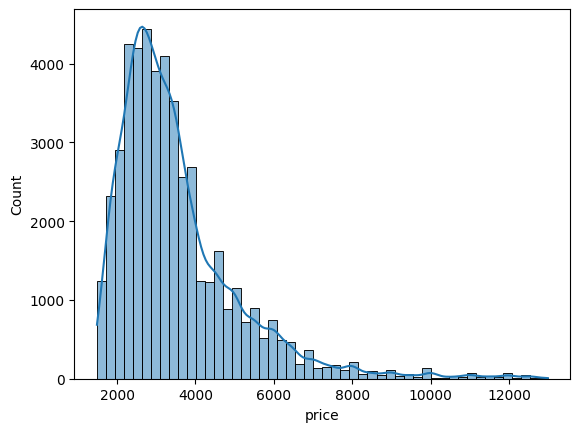

In [ ]:
import seaborn as sns
sns.histplot(Y_train, bins=50, kde=True)

# 6. Feature Selection

- Fit a Lasso regression model with normalized features. Use your method for splitting samples into 3 parts by field created with 60/20/20 ratio — train/validation/test.

In [ ]:
mae_df = pd.DataFrame(columns=['Model', 'Train', 'Val', 'Test'])
rmse_df = pd.DataFrame(columns=['Model', 'Train', 'Val', 'Test'])
r2_df = pd.DataFrame(columns=['Model', 'Train', 'Val', 'Test'])

In [ ]:
def calculate_metrics(y_true, y_pred):
    return {
        'mae': mean_absolute_error(y_true, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'r2': r2_score(y_true, y_pred)
    }

In [ ]:
def add_model_to_tables(model_name, y_train_true, y_train_pred, y_val_true, y_val_pred, y_test_true, y_test_pred):
    train_metrics = calculate_metrics(y_train_true, y_train_pred)
    val_metrics = calculate_metrics(y_val_true, y_val_pred)
    test_metrics = calculate_metrics(y_test_true, y_test_pred)

    mae_df.loc[len(mae_df)] = [model_name, train_metrics['mae'], val_metrics['mae'], test_metrics['mae']]
    rmse_df.loc[len(rmse_df)] = [model_name, train_metrics['rmse'], val_metrics['rmse'], test_metrics['rmse']]
    r2_df.loc[len(r2_df)] = [model_name, train_metrics['r2'], val_metrics['r2'], test_metrics['r2']]

## LASSO

In [ ]:
train_df = pd.read_csv("train.csv")
#удалим лишние колонки
col_to_del = ['created']
for col in col_to_del:
  if col in train_df.columns:
    train_df.drop(col, axis=1, inplace=True)

Y_train = train_df['price']
X_train = train_df.drop("price", axis=1)
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48343 entries, 0 to 48342
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bathrooms          48343 non-null  float64
 1   bedrooms           48343 non-null  int64  
 2   price              48343 non-null  int64  
 3   interest_level     48343 non-null  int64  
 4   Elevator           48343 non-null  float64
 5   HardwoodFloors     48343 non-null  float64
 6   CatsAllowed        48343 non-null  float64
 7   DogsAllowed        48343 non-null  float64
 8   Doorman            48343 non-null  float64
 9   Dishwasher         48343 non-null  float64
 10  NoFee              48343 non-null  float64
 11  LaundryinBuilding  48343 non-null  float64
 12  FitnessCenter      48343 non-null  float64
 13  Pre-War            48343 non-null  float64
 14  LaundryinUnit      48343 non-null  float64
 15  RoofDeck           48343 non-null  float64
 16  OutdoorSpace       483

In [ ]:
#делим на 3 части, используя написанный метод
X_train, X_val, X_test, Y_train, Y_val, Y_test = train_val_test_split21(X_train, Y_train, validation_size=0.2, test_size=0.2)
len(X_train), len(X_val), len(X_test), len(Y_train), len(Y_val), len(Y_test)

(29006, 9669, 9668, 29006, 9669, 9668)

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
#нормaлизуем признаки
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_val_norm = scaler.transform(X_val)
X_test_norm = scaler.transform(X_test)

X_train_norm = pd.DataFrame(X_train_norm, columns=X_train.columns, index=X_train.index)
X_val_norm = pd.DataFrame(X_val_norm, columns=X_val.columns, index=X_val.index)
X_test_norm = pd.DataFrame(X_test_norm, columns=X_test.columns, index=X_test.index)

X_train_norm.sample(5)

,bathrooms,bedrooms,interest_level,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,NoFee,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
42984,-0.426729,1.330777,-0.609901,0.947524,1.044353,-0.95469,-0.898333,1.166823,1.194178,-0.765494,...,2.184831,-0.390155,2.925263,2.975891,-0.308455,4.007787,-0.23679,-0.240502,-0.23163,4.588877
32510,-0.426729,-0.484052,1.013405,-1.055382,-0.957531,-0.95469,-0.898333,-0.857028,-0.837396,-0.765494,...,-0.457701,-0.390155,-0.341850,-0.336034,-0.308455,-0.249514,-0.23679,4.157977,-0.23163,-0.217918
25430,-0.426729,-0.484052,-0.609901,-1.055382,-0.957531,-0.95469,-0.898333,-0.857028,-0.837396,-0.765494,...,-0.457701,-0.390155,-0.341850,-0.336034,-0.308455,-0.249514,-0.23679,-0.240502,-0.23163,-0.217918
35458,-0.426729,-1.391467,-0.609901,-1.055382,-0.957531,1.04746,1.113173,-0.857028,-0.837396,-0.765494,...,-0.457701,-0.390155,-0.341850,-0.336034,-0.308455,-0.249514,-0.23679,-0.240502,-0.23163,-0.217918
32220,-0.426729,-0.484052,-0.609901,-1.055382,-0.957531,1.04746,1.113173,-0.857028,-0.837396,-0.765494,...,-0.457701,-0.390155,-0.341850,-0.336034,-0.308455,-0.249514,-0.23679,-0.240502,-0.23163,-0.217918


In [ ]:
#lasso
model = Lasso(alpha=0.5, fit_intercept=True)
model.fit(X_train, Y_train)
print(model.coef_)

features = {}
for a,b in zip(X_train.columns, model.coef_):
  features[a] = float(f"{b:.3f}")
features

[1523.33055517  467.41774895 -411.68118137  205.6511164  -113.787846
  -50.38892278  112.28721646  559.53381294  141.75725036  -80.67803079
 -193.36396913  198.91664976  -65.39411767  426.39901664 -102.89232772
  -48.74794988  122.48185807 -182.10884282    8.76604444   37.33272124
 -204.60990477 -120.2827199   152.64193087]


{'bathrooms': 1523.331,
 'bedrooms': 467.418,
 'interest_level': -411.681,
 'Elevator': 205.651,
 'HardwoodFloors': -113.788,
 'CatsAllowed': -50.389,
 'DogsAllowed': 112.287,
 'Doorman': 559.534,
 'Dishwasher': 141.757,
 'NoFee': -80.678,
 'LaundryinBuilding': -193.364,
 'FitnessCenter': 198.917,
 'Pre-War': -65.394,
 'LaundryinUnit': 426.399,
 'RoofDeck': -102.892,
 'OutdoorSpace': -48.748,
 'DiningRoom': 122.482,
 'HighSpeedInternet': -182.109,
 'Balcony': 8.766,
 'SwimmingPool': 37.333,
 'LaundryInBuilding': -204.61,
 'NewConstruction': -120.283,
 'Terrace': 152.642}

- Sort features by weight coefficients from model, fit model to top 10 features and compare quality.

In [ ]:
sorted_features = sorted(features.items(), key=lambda item: abs(item[1]))
sorted_features

[('Balcony', 8.766),
 ('SwimmingPool', 37.333),
 ('OutdoorSpace', -48.748),
 ('CatsAllowed', -50.389),
 ('Pre-War', -65.394),
 ('NoFee', -80.678),
 ('RoofDeck', -102.892),
 ('DogsAllowed', 112.287),
 ('HardwoodFloors', -113.788),
 ('NewConstruction', -120.283),
 ('DiningRoom', 122.482),
 ('Dishwasher', 141.757),
 ('Terrace', 152.642),
 ('HighSpeedInternet', -182.109),
 ('LaundryinBuilding', -193.364),
 ('FitnessCenter', 198.917),
 ('LaundryInBuilding', -204.61),
 ('Elevator', 205.651),
 ('interest_level', -411.681),
 ('LaundryinUnit', 426.399),
 ('bedrooms', 467.418),
 ('Doorman', 559.534),
 ('bathrooms', 1523.331)]

In [ ]:
sorted_features_list = [f for f,k in sorted_features[:10]]
sorted_features_list

['Balcony',
 'SwimmingPool',
 'OutdoorSpace',
 'CatsAllowed',
 'Pre-War',
 'NoFee',
 'RoofDeck',
 'DogsAllowed',
 'HardwoodFloors',
 'NewConstruction']

In [ ]:
#лассо на всех фичах
model = Lasso(alpha=0.5, fit_intercept=True)
model.fit(X_train_norm, Y_train)
y_pred_val = model.predict(X_val_norm)
y_pred_test =  model.predict(X_test_norm)
all_feat_mae_val = mean_absolute_error(y_pred_val, Y_val)
all_feat_mae_test = mean_absolute_error(y_pred_test, Y_test)
print(f"MAE on val set (all features used):{all_feat_mae_val:.3f}")
print(f"MAE on test set (all features used):{all_feat_mae_test:.3f}")

MAE on val set (all features used):695.294
MAE on test set (all features used):685.333


In [ ]:
add_model_to_tables(
    model_name="Lasso_all_features",
    y_train_true=Y_train,
    y_train_pred=model.predict(X_train_norm),
    y_val_true=Y_val,
    y_val_pred=model.predict(X_val_norm),
    y_test_true=Y_test,
    y_test_pred=model.predict(X_test_norm)
)

In [ ]:
#лассо на 10 топ фичах
X_train_10, X_val_10, X_test_10  = X_train_norm[sorted_features_list], X_val_norm[sorted_features_list],X_test_norm[sorted_features_list]

model = Lasso(alpha=0.5, fit_intercept=True)
model.fit(X_train_10, Y_train)
y_pred_val = model.predict(X_val_10)
y_pred_test =  model.predict(X_test_10)
top_feat_mae_val = mean_absolute_error(y_pred_val, Y_val)
top_feat_mae_test = mean_absolute_error(y_pred_test, Y_test)
print(f"MAE on val set (10 top features used):{top_feat_mae_val:.3f}")
print(f"MAE on test set (10 top features used):{top_feat_mae_test:.3f}")

MAE on val set (10 top features used):1126.352
MAE on test set (10 top features used):1095.400


In [ ]:
add_model_to_tables(
    model_name="Lasso_top10",
    y_train_true=Y_train,
    y_train_pred=model.predict(X_train_10),
    y_val_true=Y_val,
    y_val_pred=model.predict(X_val_10),
    y_test_true=Y_test,
    y_test_pred=model.predict(X_test_10)
)

- Как будто стало хуже, но возможно надо просто подобрать корректный коэффициент регуляризации

In [ ]:
#usual Lasso - оцениваем скорость
%%timeit
lasso_usual = Lasso(alpha=0.5, fit_intercept=True)
lasso_usual.fit(X_train_norm, Y_train)
y_pred_lasso = lasso_usual .predict(X_test_norm)
features_weights = dict(zip(X_train_norm.columns, model.coef_))
sorted_features = sorted(features_weights.items(), key=lambda x: abs(x[1]), reverse=True)
top10_features = [f for f, w in sorted_features[:10]]

The slowest run took 6.59 times longer than the fastest. This could mean that an intermediate result is being cached.
143 ms ± 95.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Self-made method

- Implement method for simple feature selection by nan-ratio in feature and correlation. Apply this method to feature set and take top 10 features, refit model and measure quality.

In [ ]:
def feature_selector_21(
    X:pd.DataFrame,
    y:pd.Series,
    max_nan_ratio:float=0.2,
    top_n:int=10
    ):
  #работаем с числовыми признаками
  X_num = X.select_dtypes(include=[np.number]).copy()
  nan_ratio = X_num.isna().mean()


  #отбираем по nan ratio, в оставленных заменяем nan на медиану
  keep = nan_ratio[nan_ratio <= max_nan_ratio].index
  X_final = X_num[keep].fillna(X_num[keep].median())

  #отбираем уже их поичщенных по nan по модулю корреляции
  corrs = X_final.apply(lambda c: np.corrcoef(c, y)[0,1])
  corrs_sorted = abs(corrs).sort_values(ascending=False)
  return corrs_sorted[:top_n].index

In [ ]:
train_df = pd.read_json ("/content/drive/MyDrive/Colab Notebooks/school21/train.json")
train_df.isna().sum()
#в датасете изначально нет NaN-ов

,0
bathrooms,0
bedrooms,0
building_id,0
created,0
description,0
display_address,0
features,0
latitude,0
listing_id,0
longitude,0


In [ ]:
train_df = pd.read_csv("train.csv")
train_df.isna().sum()
train_df.sample()

,bathrooms,bedrooms,created,price,interest_level,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
26699,1.0,1,2016-05-07 03:41:02,2150,0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
train_df.dtypes
#и после энкодинга фич тоже нет NaN-ов...

,0
bathrooms,float64
bedrooms,int64
created,object
price,int64
interest_level,int64
Elevator,float64
HardwoodFloors,float64
CatsAllowed,float64
DogsAllowed,float64
Doorman,float64


In [ ]:
#добавим в датасет колонку с NaN, чтобы проверить работу функции
new_column = np.full(len(train_df), np.nan)
non_nan_idx = np.random.choice(len(train_df), size=int(0.2*len(train_df)), replace=False)
new_column[non_nan_idx] = 0
train_df["feature_to_disappear"] = new_column
train_df.drop('created', axis=1,inplace=True)
train_df.sample()

,bathrooms,bedrooms,price,interest_level,Elevator,HardwoodFloors,CatsAllowed,DogsAllowed,Doorman,Dishwasher,...,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace,feature_to_disappear
2125,1.0,0,3097,1,1.0,0.0,1.0,1.0,1.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,NaN


In [ ]:
#прогоняем через наш селектор фич
Y_train_new = train_df["price"]
X_train = train_df.drop("price", axis=1)


selected = feature_selector_21(X_train, Y_train_new, max_nan_ratio=0.2, top_n=10 )
selected

Index(['bathrooms', 'bedrooms', 'Doorman', 'LaundryinUnit', 'FitnessCenter',
       'Dishwasher', 'DiningRoom', 'Elevator', 'interest_level',
       'OutdoorSpace'],
      dtype='object')

In [ ]:
#лассо на отобранных 10 топ фичах
X_train_10, X_val_10, X_test_10  = X_train_norm[selected], X_val_norm[selected],X_test_norm[selected]

model = Lasso(alpha=0.5, fit_intercept=True)
model.fit(X_train_10, Y_train)
y_pred_val = model.predict(X_val_10)
y_pred_test =  model.predict(X_test_10)
top_feat_mae_val = mean_absolute_error(y_pred_val, Y_val)
top_feat_mae_test = mean_absolute_error(y_pred_test, Y_test)
print(f"MAE on val set (10 top features used):{top_feat_mae_val:.3f}")
print(f"MAE on test set (10 top features used):{top_feat_mae_test:.3f}")

MAE on val set (10 top features used):704.703
MAE on test set (10 top features used):693.989


- получилось сопоставимо с базовым LASSO (691 и 679)

In [ ]:
add_model_to_tables(
    model_name="Lasso_top10_manual",
    y_train_true=Y_train,
    y_train_pred=model.predict(X_train_10),
    y_val_true=Y_val,
    y_val_pred=model.predict(X_val_10),
    y_test_true=Y_test,
    y_test_pred=model.predict(X_test_10)
)

In [ ]:
# feature_selector - оцениваем скорость
%%timeit
t = feature_selector_21(X_train_norm, Y_train, max_nan_ratio=0.5, top_n=10)
lasso_fs = Lasso(alpha=0.5, fit_intercept=True)
lasso_fs.fit(X_train_norm, Y_train)
y_pred_lasso = lasso_fs.predict(X_test_norm)
features_weights = dict(zip(X_train_norm.columns, model.coef_))
sorted_features = sorted(features_weights.items(), key=lambda x: abs(x[1]), reverse=True)
top10_features = [f for f, w in sorted_features[:10]]

87.1 ms ± 815 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


## Permutation importance

- Implement permutation importance method and take top 10 features, refit model and measure quality.

In [ ]:
def permutation_importance_21(
    X_val: pd.DataFrame,
    Y_val: pd.Series,
    model,
    top_k: int = 10,
    n_repeats: int = 10,
    random_state: int = 21,
    use_nmape: bool = False
    ):

    cols = X_val.columns.to_list()
    Y_pred_base = model.predict(X_val)

    if use_nmape:
        epsilon = 1e-8
        nmape_base = -np.mean(np.abs((Y_val - Y_pred_base) / (np.abs(Y_val) + epsilon))) * 100
        base_metric = nmape_base
    else:
        mae_base = mean_absolute_error(Y_val, Y_pred_base)
        base_metric = mae_base

    rng = np.random.RandomState(random_state)
    results = {}

    for col in cols:
        metric_list = []

        for _ in range(n_repeats):
            X = X_val.copy()
            shuffled = X[col].to_numpy(copy=True)
            rng.shuffle(shuffled)
            X[col] = shuffled

            Y_pred_j = model.predict(X)

            if use_nmape:
                nmape_perm = -np.mean(np.abs((Y_val - Y_pred_j) / (np.abs(Y_val) + epsilon))) * 100
                metric_list.append(nmape_perm)
            else:
                mae_perm = mean_absolute_error(Y_val, Y_pred_j)
                metric_list.append(mae_perm)

        if use_nmape:
            importance = base_metric - np.mean(metric_list)
        else:
            importance = np.mean(metric_list) - base_metric

        std_error = np.std(metric_list) / np.sqrt(n_repeats)

        results[col] = {
            'importance': importance,
            'std_error': std_error
        }

    if use_nmape:
        imp_df = pd.DataFrame(results).T
        imp_df = imp_df.rename(columns={'importance': 'nmape'})
        imp_df = imp_df[['nmape', 'std_error']]
    else:
        imp_df = pd.DataFrame(results).T
        imp_df = imp_df[['importance', 'std_error']]


    if use_nmape:
        imp_df_sorted = imp_df.sort_values('nmape', ascending=False)
    else:
        imp_df_sorted = imp_df.sort_values('importance', ascending=False)

    top_imp = imp_df_sorted.head(min(top_k, len(cols)))
    top_features = top_imp.index.tolist()

    return top_imp, top_features

In [ ]:
#before perm imp
model = Lasso(alpha=0.5, fit_intercept=True)
model.fit(X_train_norm, Y_train)
pi_feat, pi_top = permutation_importance_21(X_train_norm, Y_train, model)
print(pi_feat)

                   importance  std_error
bathrooms          260.726875   0.739481
bedrooms           219.493907   0.388077
Doorman             69.064194   0.475878
interest_level      57.709313   0.386750
LaundryinUnit       22.418692   0.245285
LaundryinBuilding    9.996708   0.171087
Elevator             9.295127   0.221156
FitnessCenter        6.357166   0.158406
Dishwasher           4.845786   0.091044
DogsAllowed          4.198399   0.070805


In [ ]:
#after perm imp
X_train_10, X_val_10, X_test_10  = X_train_norm[pi_top], X_val_norm[pi_top],X_test_norm[pi_top]


model = Lasso(alpha=0.5, fit_intercept=True)
model.fit(X_train_10, Y_train)

y_pred_val = model.predict(X_val_10)
y_pred_test =  model.predict(X_test_10)
top_feat_mae_val = mean_absolute_error(y_pred_val, Y_val)
top_feat_mae_test = mean_absolute_error(y_pred_test, Y_test)
print(f"MAE on val set (10 top features used):{top_feat_mae_val:.3f}")
print(f"MAE on test set (10 top features used):{top_feat_mae_test:.3f}")

MAE on val set (10 top features used):698.672
MAE on test set (10 top features used):689.694


- получилось сопоставимо с базовым LASSO (691 и 679)

In [ ]:
add_model_to_tables(
    model_name="Lasso_perm_imp",
    y_train_true=Y_train,
    y_train_pred=model.predict(X_train_10),
    y_val_true=Y_val,
    y_val_pred=model.predict(X_val_10),
    y_test_true=Y_test,
    y_test_pred=model.predict(X_test_10)
)

In [ ]:
importance_nmape, features_nmape = permutation_importance_21(
    X_val_norm[pi_top], Y_val, model,
    use_nmape=True
)
importance_nmape

,nmape,std_error
bathrooms,7.963051,0.058229
bedrooms,7.434018,0.036140
Doorman,2.709728,0.017031
interest_level,2.500089,0.032004
LaundryinUnit,0.706320,0.014366
Elevator,0.439385,0.004830
LaundryinBuilding,0.415587,0.013587
Dishwasher,0.155221,0.005459
FitnessCenter,0.133652,0.005658
DogsAllowed,0.024460,0.003630


In [ ]:
#perm importance - оцениваем скорость
%%timeit
lasso_usual = Lasso(alpha=0.5, fit_intercept=True)
lasso_usual.fit(X_train_norm, Y_train)
pi_feat, pi_top = permutation_importance_21(X_train_norm, Y_train, lasso_usual)
y_pred_lasso = lasso_usual.predict(X_test_norm)
features_weights = dict(zip(X_train_norm.columns, model.coef_))
sorted_features = sorted(features_weights.items(), key=lambda x: abs(x[1]), reverse=True)
top10_features = [f for f, w in sorted_features[:10]]

2.14 s ± 568 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## SHAP (game theory based method)

- Import Shap and also refit model on top 10 features.
Compare the quality of these methods for different aspects — speed, metrics and stability.

In [ ]:
import shap
model = Lasso(alpha=0.5, fit_intercept=True)
model.fit(X_train_norm, Y_train)
explainer = shap.LinearExplainer(model, X_train_norm)

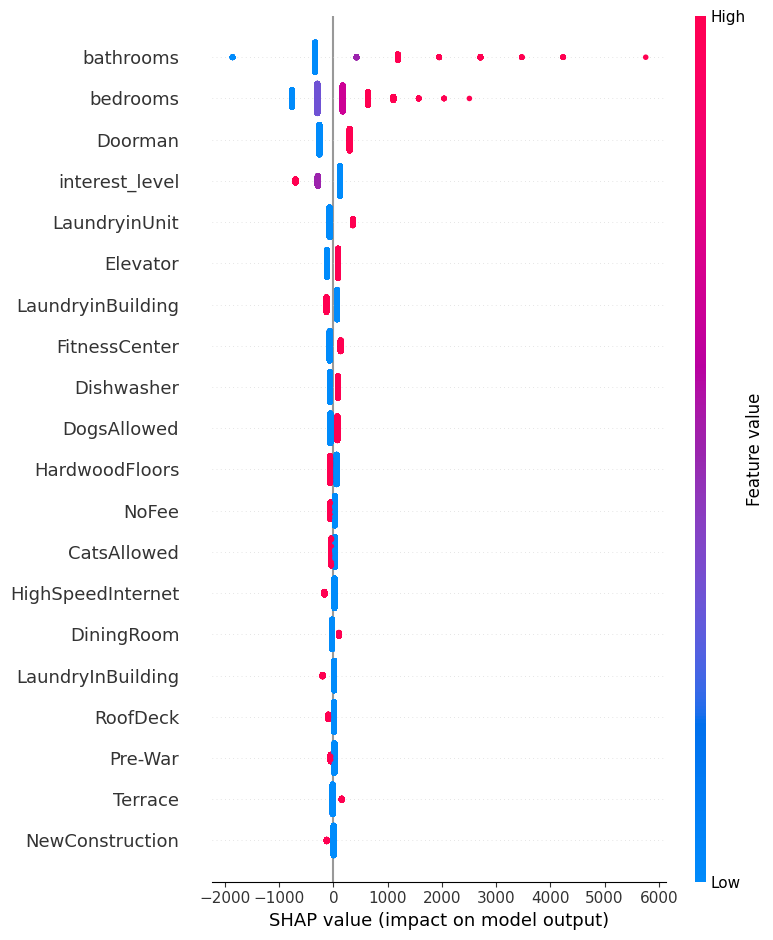

In [ ]:
shap_val = explainer.shap_values(X_val_norm)
shap.summary_plot(shap_val, X_val_norm)
plt.show()

In [ ]:
if isinstance(shap_val, list):
    shap_importance = np.abs(shap_val[1]).mean(axis=0)  #бинарн класс-ия
else:
    shap_importance = np.abs(shap_val).mean(axis=0)
importance_df = pd.DataFrame({
    'feature': X_train_norm.columns,
    'importance': shap_importance
})
top_10 = importance_df.sort_values('importance', ascending=False).head(10)
top_10_features = top_10['feature'].tolist()
print(top_10)

              feature  importance
0           bathrooms  527.516574
1            bedrooms  435.598603
7             Doorman  276.177940
2      interest_level  206.138209
13      LaundryinUnit  120.445423
3            Elevator  103.109820
10  LaundryinBuilding   88.095178
11      FitnessCenter   85.438968
8          Dishwasher   69.939171
6         DogsAllowed   63.341328


In [ ]:
#after shap
X_train_10, X_val_10, X_test_10  = X_train_norm[top_10_features], X_val_norm[top_10_features],X_test_norm[top_10_features]


model = Lasso(alpha=0.5, fit_intercept=True)
model.fit(X_train_10, Y_train)

y_pred_val = model.predict(X_val_10)
y_pred_test =  model.predict(X_test_10)
top_feat_mae_val = mean_absolute_error(y_pred_val, Y_val)
top_feat_mae_test = mean_absolute_error(y_pred_test, Y_test)
print(f"MAE on val set (10 top features used):{top_feat_mae_val:.3f}")
print(f"MAE on test set (10 top features used):{top_feat_mae_test:.3f}")

MAE on val set (10 top features used):698.672
MAE on test set (10 top features used):689.693


- получилось сопоставимо с базовым LASSO (691 и 679)

In [ ]:
add_model_to_tables(
    model_name="Lasso_SHAP",
    y_train_true=Y_train,
    y_train_pred=model.predict(X_train_10),
    y_val_true=Y_val,
    y_val_pred=model.predict(X_val_10),
    y_test_true=Y_test,
    y_test_pred=model.predict(X_test_10)
)

In [ ]:
#shap - оцениваем скорость
%%timeit
shap_val_values = explainer.shap_values(X_val_norm)
imp = pd.Series(np.abs(shap_val_values).mean(axis=0), index=X_val_norm.columns)
imp = imp.sort_values(ascending=False)
top10_shap = imp.head(10).index.tolist()

1.21 ms ± 194 µs per loop (mean ± std. dev. of 7 runs, 1000 loops each)


- Compare the quality of these methods for different aspects — speed, metrics and stability.

In [ ]:
mae_df

,Model,Train,Val,Test
0,Lasso_all_features,683.226147,695.294445,685.333428
1,Lasso_top10,1090.898859,1126.352013,1095.399631
2,Lasso_top10_manual,692.590274,704.702613,693.989131
3,Lasso_perm_imp,687.994932,698.671922,689.693512
4,Lasso_SHAP,687.994523,698.671506,689.693144


In [ ]:
rmse_df

,Model,Train,Val,Test
0,Lasso_all_features,986.735282,1013.076752,1009.208728
1,Lasso_top10,1531.059684,1581.117835,1535.433121
2,Lasso_top10_manual,999.159371,1024.711736,1020.776865
3,Lasso_perm_imp,994.048700,1019.415680,1016.048752
4,Lasso_SHAP,994.048697,1019.415612,1016.048644


In [ ]:
r2_df

,Model,Train,Val,Test
0,Lasso_all_features,0.608742,0.612115,0.585808
1,Lasso_top10,0.058010,0.055186,0.041258
2,Lasso_top10_manual,0.598827,0.603155,0.576258
3,Lasso_perm_imp,0.602921,0.607246,0.580174
4,Lasso_SHAP,0.602921,0.607246,0.580174


# 7. Hyperparameter optimization

- Implement grid search and random search methods for alpha and l1_ratio for sklearn's ElasticNet model.
- Find the best combination of model hyperparameters.
- Fit the resulting model.

In [ ]:
from sklearn.linear_model import ElasticNet
from itertools import product
from sklearn.base import clone

In [ ]:
param_grid = {
        'alpha': [0.001, 0.01, 0.5, 1.0],
        'l1_ratio': [0.001, 0.01, 0.5, 1.0]
    }

In [ ]:
#реализуем как класс с интерфейсом sklearn
class Grid_Search_en21():
    def __init__(self,
                 estimator=ElasticNet(),
                 param_grid: dict = None,
                 cv: int = 5):

        self.estimator = estimator
        self.param_grid = param_grid if param_grid is not None else {}
        self.cv = cv
        self.best_params_ = None
        self.best_score_ = None
        self.cv_results_ = None

    def fit(self, X, y):
        if not self.param_grid:
            print("Param_grid is empty!")
            return self

        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        if not isinstance(y, pd.Series):
            y = pd.Series(y)

        keys = self.param_grid.keys()
        values = self.param_grid.values()
        param_combinations = [dict(zip(keys, combination)) for combination in product(*values)]

        kf = KFold_21(k=self.cv, shuffle=True, random_state=21)

        best_score = float('inf')
        best_params = None
        results = []

        for params in param_combinations:
          model = clone(self.estimator)
          model.set_params(**params)
          fold_scores = []
          for train_idx, val_idx in kf.split(X):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model.fit(X_train, y_train)
            y_pred = model.predict(X_val)
            mae = mean_absolute_error(y_val, y_pred)
            fold_scores.append(mae)

          mean_score = np.mean(fold_scores)
          std_score = np.std(fold_scores)


          result = {
              'params': params,
              'mean_mae': mean_score,
              'std_mae': std_score,
              'fold_scores': fold_scores.copy()
          }
          results.append(result)

          print(f"MAE: {mean_score:.3f} ± {std_score:.3f}")

          if mean_score < best_score:
              best_score = mean_score
              best_params = params


        self.best_params_ = best_params
        self.best_score_ = best_score
        self.cv_results_ = results
        self.best_estimator_ = clone(self.estimator).set_params(**best_params)
        self.best_estimator_.fit(X, y)
        print(f"\nBest parameters: {best_params}")
        print(f"Best MAE: {best_score:.4f}")
        return self

    def predict(self, X):
        if self.best_estimator_ is None:
            raise ValueError("GridSearchCV hasn't been fitted yet!")
        return self.best_estimator_.predict(X)

    def score(self, X, y):
        if self.best_estimator_ is None:
            raise ValueError("GridSearchCV hasn't been fitted yet!")
        return self.best_estimator_.score(X, y)

In [ ]:
grid_search = Grid_Search_en21(estimator=ElasticNet(max_iter=10000, random_state=21), param_grid=param_grid, cv=5)
grid_search.fit(X_train_norm, Y_train)
predictions = grid_search.predict(X_test_norm)

MAE: 683.886 ± 4.168
MAE: 683.886 ± 4.168
MAE: 683.910 ± 4.166
MAE: 683.934 ± 4.165
MAE: 683.485 ± 4.194
MAE: 683.489 ± 4.194
MAE: 683.697 ± 4.178
MAE: 683.931 ± 4.165
MAE: 707.763 ± 5.027
MAE: 707.355 ± 5.020
MAE: 688.153 ± 4.727
MAE: 683.782 ± 4.157
MAE: 754.713 ± 5.732
MAE: 753.907 ± 5.717
MAE: 707.990 ± 5.031
MAE: 683.645 ± 4.148

Best parameters: {'alpha': 0.01, 'l1_ratio': 0.001}
Best MAE: 683.4851


In [ ]:
class Random_Search_en21():
    def __init__(self,
                 estimator=ElasticNet(),
                 param_grid: dict = None,
                 cv: int = 5,
                 n_iter: int = 10,
                 random_state: int = 21):

        self.estimator = estimator
        self.param_grid = param_grid if param_grid is not None else {}
        self.cv = cv
        self.n_iter = n_iter
        self.random_state = random_state
        self.best_params_ = None
        self.best_score_ = None
        self.cv_results_ = None
        self.best_estimator_ = None

    def fit(self, X, y):
        if not self.param_grid:
            print("param_grid is empty!")
            return self

        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        if not isinstance(y, pd.Series):
            y = pd.Series(y)

        kf = KFold_21(k=self.cv, shuffle=True, random_state=self.random_state)

        rng = np.random.RandomState(self.random_state)

        best_score = float('inf')
        best_params = None
        results = []

        param_combinations = []
        for _ in range(self.n_iter):
            params = {}
            for param_name, param_values in self.param_grid.items():
                if isinstance(param_values, list):
                    params[param_name] = rng.choice(param_values)
                elif hasattr(param_values, 'rvs'):
                    params[param_name] = param_values.rvs(random_state=rng)
                else:
                    raise ValueError(f"Unsupported parameter distribution for {param_name}")
            param_combinations.append(params)

        for i, params in enumerate(param_combinations):
            model = clone(self.estimator)
            model.set_params(**params)
            fold_scores = []

            for train_idx, val_idx in kf.split(X):
                X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
                y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

                model.fit(X_train, y_train)
                y_pred = model.predict(X_val)

                mae = mean_absolute_error(y_val, y_pred)
                fold_scores.append(mae)

            mean_score = np.mean(fold_scores)
            std_score = np.std(fold_scores)

            result = {
                'params': params,
                'mean_mae': mean_score,
                'std_mae': std_score,
                'fold_scores': fold_scores,
                'iteration': i + 1
            }
            results.append(result)

            print(f"MAE: {mean_score:.4f} ± {std_score:.4f}")

            if mean_score < best_score:
                best_score = mean_score
                best_params = params

        results_sorted = sorted(results, key=lambda x: x['mean_mae'])

        self.best_params_ = best_params
        self.best_score_ = best_score
        self.cv_results_ = results_sorted
        self.best_estimator_ = clone(self.estimator).set_params(**best_params)
        self.best_estimator_.fit(X, y)

        print(f"Best parameters: {best_params}")
        print(f"Best MAE: {best_score:.4f}")

        return self

    def predict(self, X):
        if self.best_estimator_ is None:
            raise ValueError("RandomSearchCV hasn't been fitted yet!")
        return self.best_estimator_.predict(X)

    def score(self, X, y):
        if self.best_estimator_ is None:
            raise ValueError("RandomSearchCV hasn't been fitted yet!")
        return self.best_estimator_.score(X, y)

In [ ]:
random_search = Random_Search_en21(estimator=ElasticNet(max_iter=10000, random_state=21), param_grid=param_grid, cv=5)
random_search.fit(X_train_norm, Y_train)
predictions = random_search.predict(X_test_norm)

MAE: 683.9312 ± 4.1647
MAE: 683.8856 ± 4.1676
MAE: 683.8856 ± 4.1676
MAE: 683.9341 ± 4.1649
MAE: 683.9097 ± 4.1663
MAE: 753.9074 ± 5.7173
MAE: 707.7630 ± 5.0274
MAE: 683.7816 ± 4.1571
MAE: 683.8860 ± 4.1676
MAE: 683.4888 ± 4.1936
Best parameters: {'alpha': np.float64(0.01), 'l1_ratio': np.float64(0.01)}
Best MAE: 683.4888


- Import optuna and configure the same experiment with ElasticNet.
- Estimate metrics and compare approaches.
- Run optuna on one of the cross-validation schemes.

In [ ]:
!pip install optuna
import optuna

- быстрый прогон без кросс-валидации

In [ ]:
def simple_objective(trial):
    alpha = trial.suggest_float('alpha', 0.001, 2.0, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)

    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=21)
    model.fit(X_train_norm, Y_train)

    y_pred = model.predict(X_val_norm)
    return mean_absolute_error(Y_val, y_pred)

study = optuna.create_study(direction='minimize')
study.optimize(simple_objective, n_trials=20)

print(f"Best MAE: {study.best_value:.3f}")
print(f"Best params: {study.best_params}")

[I 2025-11-22 14:30:48,085] A new study created in memory with name: no-name-054e9f83-f7bf-4128-9d4f-75ea43e51b08
[I 2025-11-22 14:30:48,257] Trial 0 finished with value: 737.6203390890906 and parameters: {'alpha': 0.9602703507234133, 'l1_ratio': 0.3950046008003463}. Best is trial 0 with value: 737.6203390890906.
[I 2025-11-22 14:30:48,814] Trial 1 finished with value: 695.3807927434015 and parameters: {'alpha': 0.0012315185529631354, 'l1_ratio': 0.0439919139662065}. Best is trial 1 with value: 695.3807927434015.
[I 2025-11-22 14:30:49,167] Trial 2 finished with value: 695.3466328956702 and parameters: {'alpha': 0.0036301379622764632, 'l1_ratio': 0.1570194412814403}. Best is trial 2 with value: 695.3466328956702.
[I 2025-11-22 14:30:49,361] Trial 3 finished with value: 695.1834088551116 and parameters: {'alpha': 0.07098674916763276, 'l1_ratio': 0.8113103896199889}. Best is trial 3 with value: 695.1834088551116.
[I 2025-11-22 14:30:49,722] Trial 4 finished with value: 695.212490902132 a

Best MAE: 695.120
Best params: {'alpha': 0.07264041931304392, 'l1_ratio': 0.6191439003122773}


- дает похожие результаты как по метрике, так и по значениям параметров, но отрабатывает быстрее.

- с кросс-валидацией (как хотят в задании)

In [ ]:
def run_optuna(trial):
    alpha = trial.suggest_float('alpha', 0.001, 2.0, log=True)
    l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)


    #чтоб меньше ругался на сходимость
    max_iter = trial.suggest_int('max_iter', 1000, 10000)
    tol = trial.suggest_float('tol', 1e-6, 1e-3, log=True)

    model = ElasticNet(
        alpha=alpha,
        l1_ratio=l1_ratio,
        max_iter=max_iter,
        random_state=21
    )

    #KFold_21)
    kf = KFold_21(k=5, shuffle=True, random_state=21)
    scores = []

    for train_idx, val_idx in kf.split(X_train_norm):
        X_train_fold, X_val_fold = X_train_norm.iloc[train_idx], X_train_norm.iloc[val_idx]
        y_train_fold, y_val_fold = Y_train.iloc[train_idx], Y_train.iloc[val_idx]

        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)
        mae = mean_absolute_error(y_val_fold, y_pred)
        scores.append(mae)

    return np.mean(scores)

In [ ]:
study = optuna.create_study(direction='minimize')
study.optimize(run_optuna, n_trials=50)

print("Best trial:")
trial = study.best_trial
print(f"MAE: {trial.value:.4f}")
print(f"Params: {trial.params}")

[I 2025-11-22 14:34:29,570] A new study created in memory with name: no-name-dcdcb9a0-309c-40e4-ab71-3a78de6422e7
[I 2025-11-22 14:34:30,598] Trial 0 finished with value: 682.8267579705904 and parameters: {'alpha': 1.0139939504212143, 'l1_ratio': 0.977246887362612, 'max_iter': 7142, 'tol': 2.571533857657413e-05}. Best is trial 0 with value: 682.8267579705904.
[I 2025-11-22 14:34:33,072] Trial 1 finished with value: 683.3689220043234 and parameters: {'alpha': 0.013778865560889569, 'l1_ratio': 0.06193158544173605, 'max_iter': 1545, 'tol': 4.754558887704847e-05}. Best is trial 0 with value: 682.8267579705904.
[I 2025-11-22 14:34:34,762] Trial 2 finished with value: 683.839277601072 and parameters: {'alpha': 0.0021220157867181165, 'l1_ratio': 0.07582171915475655, 'max_iter': 3291, 'tol': 1.7502864499277434e-05}. Best is trial 0 with value: 682.8267579705904.
[I 2025-11-22 14:34:35,165] Trial 3 finished with value: 682.2981387897182 and parameters: {'alpha': 0.7759710627402269, 'l1_ratio': 

Best trial:
MAE: 682.2061
Params: {'alpha': 1.0889740359434865, 'l1_ratio': 0.9359361238881339, 'max_iter': 7936, 'tol': 2.3031117589643088e-05}
